## MLflow Cleanup

End any active runs from previous sessions.

In [25]:
# MLflow Cleanup
import mlflow

print('Checking for active MLflow runs...')
active_run = mlflow.active_run()
if active_run:
    print(f'⚠️  Found active run - ending it')
    mlflow.end_run()
    print('   ✓ Ended')
else:
    print('✓ No active runs')
print('Ready to train!')

Checking for active MLflow runs...
⚠️  Found active run - ending it
   ✓ Ended
Ready to train!


# Notebook 05: Classical Training - Baseline Models (Optimized)

**Purpose:** Train baseline classical ML models with maximum parallelization (no hyperparameter tuning, no resampling)

**Performance Optimizations:**
1. All models use n_jobs=-1 (full CPU parallelization)
2. No data resampling - use class_weight='balanced' instead
3. No hyperparameter tuning - pure baseline training
4. Immediate model saves after training
5. Memory-efficient processing

**Models Trained:**
- LinearSVC (fast linear SVM)
- Random Forest
- XGBoost
- Gradient Boosting
- K-Nearest Neighbors
- Gaussian Mixture Model

**Strategy:**
- Train on unbalanced data (more realistic)
- Use class_weight='balanced' in models
- Fair comparison across feature sets and sampling rates

**Expected Time:** ~2-5 minutes

---

## 1. Import Libraries

In [26]:
import os
import sys
from pathlib import Path
import json
from datetime import datetime
import time
import warnings
from multiprocessing import cpu_count
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                            classification_report, confusion_matrix)

# XGBoost
import xgboost as xgb

# MLflow
import mlflow

print('✓ All libraries imported successfully')
print(f'Available CPU cores: {cpu_count()}')

✓ All libraries imported successfully
Available CPU cores: 10


## 2. Configuration

In [27]:
# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_DIR = DATA_DIR / 'features' / 'classical'
MODELS_DIR = PROJECT_ROOT / 'models' / 'classical'
RESULTS_DIR = PROJECT_ROOT / 'results'

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Which feature set to use
FEATURE_SET = 'combined'  # Options: 'mfcc', 'gfcc', 'combined'

# Processing parameters
N_JOBS = -1  # Use all CPU cores
RANDOM_STATE = 42
TEST_SIZE = 0.3
VAL_SIZE = 0.15  # 15% of remaining 70%

# Cross-validation
CV_FOLDS = 5

print(f'Project root: {PROJECT_ROOT}')
print(f'Features directory: {FEATURES_DIR}')
print(f'Models directory: {MODELS_DIR}')
print(f'Results directory: {RESULTS_DIR}')
print(f'\nFeature set: {FEATURE_SET}')
print(f'Parallel jobs: {N_JOBS} (all cores)')
print(f'CV folds: {CV_FOLDS}')
print(f'\nStrategy: Train on unbalanced data with class_weight="balanced"')

Project root: /Users/harryirving/Development/projects/ai-ml/BikeAIv5
Features directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/data/features/classical
Models directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical
Results directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results

Feature set: combined
Parallel jobs: -1 (all cores)
CV folds: 5

Strategy: Train on unbalanced data with class_weight="balanced"


## 3. Load Features

In [28]:
print('Loading features...')

# Load features
features_path = FEATURES_DIR / f'{FEATURE_SET}_unbalanced_features.npy'
labels_path = FEATURES_DIR / 'labels.npy'

if not features_path.exists():
    raise FileNotFoundError(f'Features not found at {features_path}. Run notebook 03 first.')

X = np.load(features_path)
y = np.load(labels_path)

print(f'✓ Loaded features: {X.shape}')
print(f'  Feature dimension: {X.shape[1]}')
print(f'  Total samples: {len(y)}')

# Check class distribution
print(f'\nClass distribution:')
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    class_name = 'Non-grinder' if label == 0 else 'Grinder'
    print(f'  {class_name} (label={label}): {count} ({count/len(y)*100:.1f}%)')

# Check for NaN or Inf
n_nan = np.isnan(X).sum()
n_inf = np.isinf(X).sum()
print(f'\nData quality: NaN={n_nan}, Inf={n_inf}')

if n_nan > 0 or n_inf > 0:
    print('Cleaning invalid values...')
    X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
    print('✓ Data cleaned')

Loading features...
✓ Loaded features: (59869, 248)
  Feature dimension: 248
  Total samples: 59869

Class distribution:
  Non-grinder (label=0): 27077 (45.2%)
  Grinder (label=1): 32792 (54.8%)

Data quality: NaN=0, Inf=0


## 4. Split and Scale Data (No Balancing)

In [29]:
print('\nSplitting data (no balancing)...')
start_time = time.time()

# Split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Split validation from train
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train
)

print(f'Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}')

# Check class distribution (unbalanced)
print(f'\nTraining set class distribution (unbalanced):')
unique, counts = np.unique(y_train, return_counts=True)
for label_val, count in zip(unique, counts):
    class_name = 'Non-grinder' if label_val == 0 else 'Grinder'
    print(f'  {class_name}: {count} ({count/len(y_train)*100:.1f}%)')

print(f'\nNote: Using class_weight="balanced" in models to handle imbalance')

# Scale features
print(f'\nScaling features...')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler
scaler_path = MODELS_DIR / f'{FEATURE_SET}_scaler.pkl'
joblib.dump(scaler, scaler_path)

prep_time = time.time() - start_time
print(f'\n✓ Data preparation complete in {prep_time:.2f} seconds')
print(f'✓ Scaler saved to: {scaler_path}')


Splitting data (no balancing)...
Train: 35621, Val: 6287, Test: 17961

Training set class distribution (unbalanced):
  Non-grinder: 16111 (45.2%)
  Grinder: 19510 (54.8%)

Note: Using class_weight="balanced" in models to handle imbalance

Scaling features...

✓ Data preparation complete in 0.17 seconds
✓ Scaler saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical/combined_scaler.pkl


## 5. Define Baseline Models

In [30]:
def get_baseline_models():
    """
    Return dictionary of baseline models with reasonable parameters.
    All models use n_jobs=-1 where supported and class_weight='balanced'.
    """
    models = {
        'LinearSVC': LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=2000,
            class_weight='balanced'
        ),
        
        'RandomForest': RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            class_weight='balanced'
        ),
        
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            eval_metric='logloss',
            use_label_encoder=False,
            scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])  # Handle imbalance
        ),
        
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ),
        
        'KNN': KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=N_JOBS
        ),
        
        'GMM': GaussianMixture(
            n_components=2,
            random_state=RANDOM_STATE,
            covariance_type='diag'
        )
    }
    
    return models


print('✓ Baseline models defined')
print('\nModels to train (all with n_jobs=-1 and class weighting):')
for model_name in ['LinearSVC', 'RandomForest', 'XGBoost', 'GradientBoosting', 'KNN', 'GMM']:
    print(f'  - {model_name}')

✓ Baseline models defined

Models to train (all with n_jobs=-1 and class weighting):
  - LinearSVC
  - RandomForest
  - XGBoost
  - GradientBoosting
  - KNN
  - GMM


## 6. Training Function

In [31]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Train a model and evaluate on train/val/test sets.
    """
    print(f'\n{"="*80}')
    print(f'Training: {model_name}')
    print('='*80)
    
    # Training
    print('Training...')
    train_start = time.time()
    
    if model_name == 'GMM':
        model.fit(X_train)
    else:
        model.fit(X_train, y_train)
    
    train_time = time.time() - train_start
    print(f'✓ Training complete in {train_time:.2f}s')
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Compute metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    test_f1 = f1_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    
    # Cross-validation
    print('Running cross-validation...')
    cv_start = time.time()
    try:
        if model_name == 'GMM':
            cv_mean = None
            cv_std = None
        else:
            cv_scores = cross_val_score(
                model, X_train, y_train, cv=CV_FOLDS, scoring='accuracy', n_jobs=N_JOBS
            )
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
    except Exception as e:
        print(f'CV failed: {e}')
        cv_mean = None
        cv_std = None
    
    cv_time = time.time() - cv_start
    
    # Inference time
    inference_start = time.time()
    _ = model.predict(X_test[:100])
    inference_time = (time.time() - inference_start) / 100 * 1000
    
    train_test_gap = train_acc - test_acc
    
    # Print results
    print(f'\nResults:')
    print(f'  Train Time: {train_time:.2f}s')
    print(f'  CV Time: {cv_time:.2f}s')
    print(f'  Inference Time: {inference_time:.3f}ms/sample')
    print(f'\n  Train Accuracy: {train_acc:.4f}')
    print(f'  Val Accuracy: {val_acc:.4f}')
    print(f'  Test Accuracy: {test_acc:.4f}')
    if cv_mean is not None:
        print(f'  CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}')
    print(f'\n  Test F1: {test_f1:.4f}')
    print(f'  Test Precision: {test_precision:.4f}')
    print(f'  Test Recall: {test_recall:.4f}')
    print(f'\n  Train-Test Gap: {train_test_gap:.4f}')
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    print(f'\n  Confusion Matrix:')
    print(f'    TN={cm[0,0]}, FP={cm[0,1]}')
    print(f'    FN={cm[1,0]}, TP={cm[1,1]}')
    
    fpr = cm[0,1] / (cm[0,1] + cm[0,0]) if (cm[0,1] + cm[0,0]) > 0 else 0
    fnr = cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    print(f'  FPR: {fpr:.4f} (false alarms)')
    print(f'  FNR: {fnr:.4f} (missed thefts - CRITICAL!)')
    
    # Save model
    model_path = MODELS_DIR / f'{FEATURE_SET}_{model_name}_baseline.pkl'
    joblib.dump(model, model_path)
    print(f'\n✓ Model saved to: {model_path}')
    
    return {
        'model_name': model_name,
        'model': model,
        'train_time': train_time,
        'cv_time': cv_time,
        'inference_time': inference_time,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'test_f1': test_f1,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'train_test_gap': train_test_gap,
        'fpr': fpr,
        'fnr': fnr,
        'confusion_matrix': cm,
        'model_path': str(model_path)
    }


print('✓ Training function defined')

✓ Training function defined


## 7. Train All Models

In [33]:
# Initialize MLflow
mlflow.set_experiment('angle_grinder_pipeline')
run_name = f'baseline_training_optimized_{FEATURE_SET}_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_param('training_type', 'baseline_optimized_unbalanced')
    mlflow.log_param('feature_set', FEATURE_SET)
    mlflow.log_param('n_jobs', N_JOBS)
    mlflow.log_param('test_size', TEST_SIZE)
    mlflow.log_param('cv_folds', CV_FOLDS)
    mlflow.log_param('resampling', 'none')
    mlflow.log_param('n_features', X.shape[1])
    mlflow.log_param('n_samples', len(y))
    
    print('\n' + '='*80)
    print('TRAINING BASELINE MODELS (OPTIMIZED - UNBALANCED DATA)')
    print('='*80)
    print(f'Feature set: {FEATURE_SET}')
    print(f'Parallelization: n_jobs={N_JOBS}')
    print(f'No resampling - using class_weight="balanced"')
    
    total_start_time = time.time()
    
    models = get_baseline_models()
    results = {}
    
    for model_name, model in models.items():
        result = train_and_evaluate_model(
            model=model,
            model_name=model_name,
            X_train=X_train_scaled,
            y_train=y_train,
            X_val=X_val_scaled,
            y_val=y_val,
            X_test=X_test_scaled,
            y_test=y_test
        )
        
        results[model_name] = result
        
        mlflow.log_metric(f'{model_name}_train_time', result['train_time'])
        mlflow.log_metric(f'{model_name}_test_acc', result['test_acc'])
        mlflow.log_metric(f'{model_name}_test_f1', result['test_f1'])
        if result['cv_mean'] is not None:
            mlflow.log_metric(f'{model_name}_cv_mean', result['cv_mean'])
    
    total_time = time.time() - total_start_time
    
    print('\n' + '='*80)
    print('TRAINING COMPLETE')
    print('='*80)
    print(f'Total time: {total_time:.2f}s ({total_time/60:.2f} minutes)')
    print(f'Average per model: {total_time/len(models):.2f}s')
    
    mlflow.log_metric('total_training_time_seconds', total_time)


TRAINING BASELINE MODELS (OPTIMIZED - UNBALANCED DATA)
Feature set: combined
Parallelization: n_jobs=-1
No resampling - using class_weight="balanced"

Training: LinearSVC
Training...
✓ Training complete in 7.34s
Running cross-validation...

Results:
  Train Time: 7.34s
  CV Time: 11.23s
  Inference Time: 0.077ms/sample

  Train Accuracy: 0.9445
  Val Accuracy: 0.9394
  Test Accuracy: 0.9433
  CV Accuracy: 0.9415 ± 0.0030

  Test F1: 0.9486
  Test Precision: 0.9417
  Test Recall: 0.9556

  Train-Test Gap: 0.0013

  Confusion Matrix:
    TN=7541, FP=582
    FN=437, TP=9401
  FPR: 0.0716 (false alarms)
  FNR: 0.0444 (missed thefts - CRITICAL!)

✓ Model saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical/combined_LinearSVC_baseline.pkl

Training: RandomForest
Training...
✓ Training complete in 12.29s
Running cross-validation...

Results:
  Train Time: 12.29s
  CV Time: 33.76s
  Inference Time: 0.700ms/sample

  Train Accuracy: 1.0000
  Val Accuracy: 0.9755
  

/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:23:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:23:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:23:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:23:39] WARNING: /Users


Results:
  Train Time: 2.90s
  CV Time: 12.03s
  Inference Time: 0.020ms/sample

  Train Accuracy: 1.0000
  Val Accuracy: 0.9835
  Test Accuracy: 0.9839
  CV Accuracy: 0.9828 ± 0.0011

  Test F1: 0.9854
  Test Precision: 0.9778
  Test Recall: 0.9931

  Train-Test Gap: 0.0161

  Confusion Matrix:
    TN=7901, FP=222
    FN=68, TP=9770
  FPR: 0.0273 (false alarms)
  FNR: 0.0069 (missed thefts - CRITICAL!)

✓ Model saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models/classical/combined_XGBoost_baseline.pkl

Training: GradientBoosting
Training...
✓ Training complete in 225.65s
Running cross-validation...

Results:
  Train Time: 225.65s
  CV Time: 349.78s
  Inference Time: 0.017ms/sample

  Train Accuracy: 0.9618
  Val Accuracy: 0.9544
  Test Accuracy: 0.9563
  CV Accuracy: 0.9563 ± 0.0018

  Test F1: 0.9607
  Test Precision: 0.9459
  Test Recall: 0.9760

  Train-Test Gap: 0.0055

  Confusion Matrix:
    TN=7574, FP=549
    FN=236, TP=9602
  FPR: 0.0676 (false alarms)
  

## 8. Create Results DataFrame

In [34]:
results_data = []

for model_name, result in results.items():
    results_data.append({
        'Model': model_name,
        'Train Time (s)': result['train_time'],
        'Inference (ms)': result['inference_time'],
        'Train Acc': result['train_acc'],
        'Val Acc': result['val_acc'],
        'Test Acc': result['test_acc'],
        'CV Mean': result['cv_mean'] if result['cv_mean'] is not None else 0,
        'Test F1': result['test_f1'],
        'Test Precision': result['test_precision'],
        'Test Recall': result['test_recall'],
        'FPR': result['fpr'],
        'FNR': result['fnr']
    })

df_results = pd.DataFrame(results_data).sort_values('Test F1', ascending=False)
results_path = RESULTS_DIR / f'05_baseline_results_{FEATURE_SET}_optimized.csv'
df_results.to_csv(results_path, index=False)

print('\n' + '='*80)
print('RESULTS SUMMARY')
print('='*80)
print(df_results.to_string(index=False))
print(f'\n✓ Results saved to: {results_path}')
mlflow.log_artifact(str(results_path))


RESULTS SUMMARY
           Model  Train Time (s)  Inference (ms)  Train Acc  Val Acc  Test Acc  CV Mean  Test F1  Test Precision  Test Recall      FPR      FNR
         XGBoost        2.895360        0.020001   1.000000 0.983458  0.983854 0.982791 0.985376        0.977782     0.993088 0.027330 0.006912
    RandomForest       12.291077        0.699792   1.000000 0.975505  0.976393 0.975436 0.978728        0.966317     0.991462 0.041856 0.008538
             KNN        0.015568        2.448258   0.980040 0.964689  0.968988 0.966087 0.972126        0.957417     0.987294 0.053182 0.012706
GradientBoosting      225.646140        0.017228   0.961792 0.954350  0.956294 0.956262 0.960728        0.945917     0.976011 0.067586 0.023989
       LinearSVC        7.338740        0.077131   0.944527 0.939399  0.943266 0.941467 0.948590        0.941701     0.955580 0.071648 0.044420
             GMM        0.971631        0.001929   0.378962 0.382376  0.379990 0.000000 0.333652        0.405586     0.

## 9. Identify Best Model

In [35]:
print('\n' + '='*80)
print('BEST MODEL')
print('='*80)

best_idx = df_results['Test F1'].idxmax()
best_row = df_results.loc[best_idx]
best_model_name = best_row['Model']
best_model = results[best_model_name]['model']

print(f'Best Model (by Test F1): {best_model_name}')
print(f'  Test Accuracy: {best_row["Test Acc"]:.4f}')
print(f'  Test F1: {best_row["Test F1"]:.4f}')
print(f'  Test Recall: {best_row["Test Recall"]:.4f}')
print(f'  FNR (Missed Thefts): {best_row["FNR"]:.4f}')

y_pred_best = best_model.predict(X_test_scaled)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Non-grinder', 'Grinder'], digits=4))

mlflow.log_param('best_model', best_model_name)
mlflow.log_metric('best_test_f1', best_row['Test F1'])
print('='*80)


BEST MODEL
Best Model (by Test F1): XGBoost
  Test Accuracy: 0.9839
  Test F1: 0.9854
  Test Recall: 0.9931
  FNR (Missed Thefts): 0.0069

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-grinder     0.9915    0.9727    0.9820      8123
     Grinder     0.9778    0.9931    0.9854      9838

    accuracy                         0.9839     17961
   macro avg     0.9846    0.9829    0.9837     17961
weighted avg     0.9840    0.9839    0.9838     17961



## 10. Visualizations


✓ Visualization saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/05_baseline_comparison_combined_optimized.png


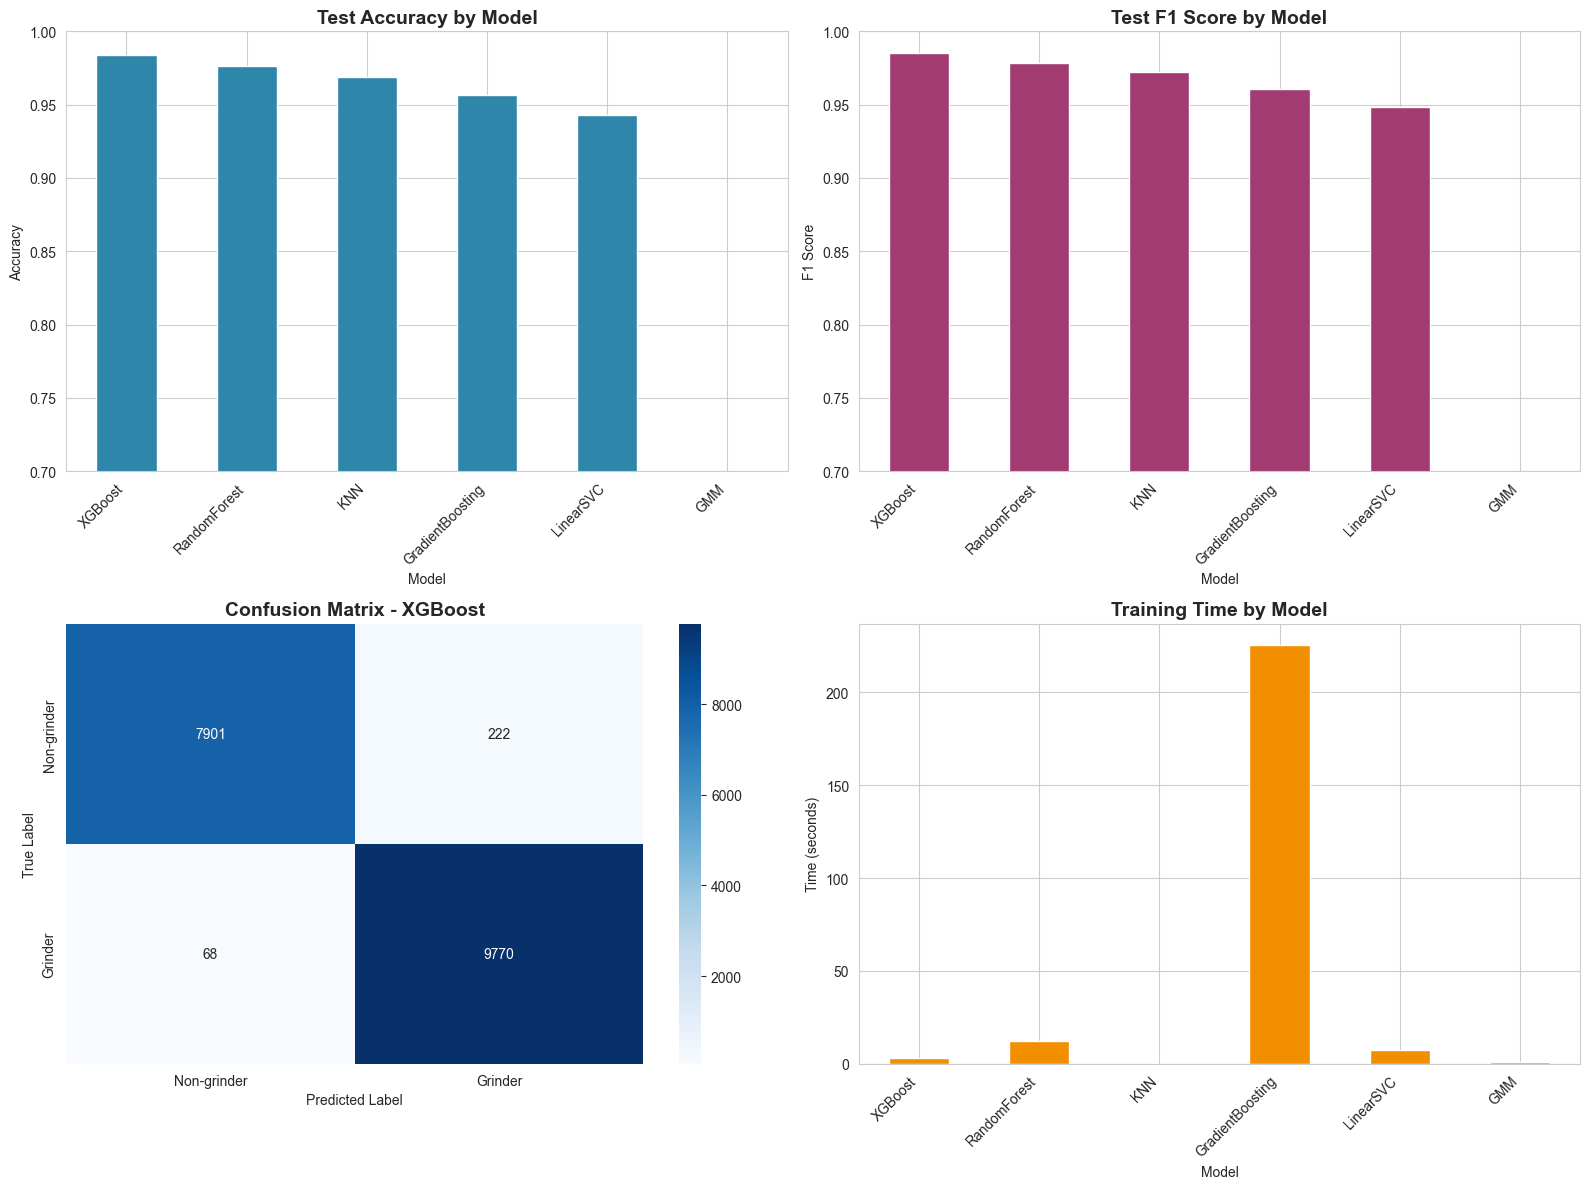

In [36]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Accuracy
ax1 = axes[0, 0]
df_results.plot(x='Model', y='Test Acc', kind='bar', ax=ax1, color='#2E86AB', legend=False)
ax1.set_title('Test Accuracy by Model', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([0.7, 1.0])
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# F1 Score
ax2 = axes[0, 1]
df_results.plot(x='Model', y='Test F1', kind='bar', ax=ax2, color='#A23B72', legend=False)
ax2.set_title('Test F1 Score by Model', fontsize=14, fontweight='bold')
ax2.set_ylabel('F1 Score')
ax2.set_ylim([0.7, 1.0])
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Confusion Matrix
ax3 = axes[1, 0]
cm = results[best_model_name]['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Non-grinder', 'Grinder'],
            yticklabels=['Non-grinder', 'Grinder'])
ax3.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')

# Training Time
ax4 = axes[1, 1]
df_results.plot(x='Model', y='Train Time (s)', kind='bar', ax=ax4, color='#F18F01', legend=False)
ax4.set_title('Training Time by Model', fontsize=14, fontweight='bold')
ax4.set_ylabel('Time (seconds)')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
fig_path = RESULTS_DIR / f'05_baseline_comparison_{FEATURE_SET}_optimized.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'\n✓ Visualization saved to: {fig_path}')
mlflow.log_artifact(str(fig_path))
plt.show()

## Notebook Complete

**Summary:**
- Trained 6 baseline models on unbalanced data
- Used class_weight='balanced' for fair class handling
- No hyperparameter tuning
- Fast and realistic performance assessment

**Next Steps:**
- Use notebook 05c to compare against 44.1kHz features
- Evaluate deployment viability on ESP32
- Consider hyperparameter tuning if baseline insufficient